## POST LAB

First 5 rows:(24EU02022)
   PassengerId  Survived  Pclass            Name     Sex  Age  SibSp  Parch  \
0            1         0       3      John Smith    male   22      1      0   
1            2         1       1    Mary Johnson  female   38      1      0   
2            3         1       3     David Brown    male   26      0      0   
3            4         1       1     Emily Davis  female   35      1      0   
4            5         0       3  Michael Wilson    male   35      0      0   

   Ticket   Fare Cabin Embarked  
0  A12345   7.25   NaN        S  
1  B23456  71.28   C85        C  
2  C34567   7.92   NaN        S  
3  D45678  53.10  C123        S  
4  E56789   8.05   NaN        S  

Scaled Data:(24EU02022)
[[-0.4487118  -0.88297518  0.33333333 -0.46852129]
 [ 0.747853    1.97675677  0.33333333 -0.46852129]
 [-0.1495706  -0.85305139 -0.77777778 -0.46852129]
 [ 0.5234971   1.16479477  0.33333333 -0.46852129]
 [ 0.5234971  -0.84724528 -0.77777778 -0.46852129]]

Explained Vari

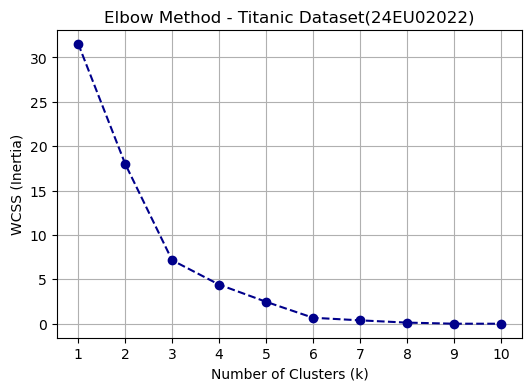


Clustered Data:(24EU02022)
        PC1       PC2  Cluster
0 -0.595529 -0.240377        1
1  1.272790  1.669795        0
2  0.152615 -0.972620        1
3  0.820348  1.118097        0
4  0.609929 -1.023056        1


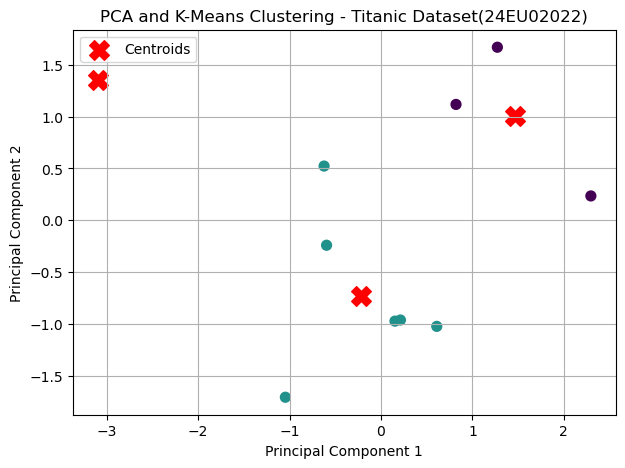

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Load Titanic Dataset
df = pd.read_csv("titanic-Dataset.csv")

# Display dataset
print("First 5 rows:(24EU02022)")
print(df.head())

# Select numerical features
X = df[['Age', 'Fare', 'SibSp', 'Parch']]

# Handle missing values
X = X.copy()
X['Age'] = X['Age'].fillna(X['Age'].median())

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nScaled Data:(24EU02022)")
print(X_scaled[:5])

# ---------------- PCA ----------------

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("\nExplained Variance Ratio:(24EU02022)")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Explained:(24EU02022)")
print(sum(pca.explained_variance_ratio_))

# PCA DataFrame
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

print("\nPCA Data:(24EU02022)")
print(pca_df.head())

# ---------------- ELBOW METHOD ----------------

wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(6, 4))
plt.plot(
    k_range,
    wcss,
    marker='o',
    linestyle='--',
    color='darkblue'
)

plt.title("Elbow Method - Titanic Dataset(24EU02022)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(k_range)
plt.grid(True)
plt.show()

# ---------------- K-MEANS CLUSTERING ----------------

# Choose number of clusters
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_pca)

# Add cluster labels
pca_df['Cluster'] = clusters

print("\nClustered Data:(24EU02022)")
print(pca_df.head())

# ---------------- CLUSTER VISUALIZATION ----------------

plt.figure(figsize=(7, 5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap='viridis',
    s=50
)

# Plot cluster centers
centers = kmeans.cluster_centers_

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker='X',
    s=200,
    color='red',
    label='Centroids'
)

plt.title("PCA and K-Means Clustering - Titanic Dataset(24EU02022)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()